<a href="https://colab.research.google.com/github/kashishkumar2005/MLLab/blob/main/Lab6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

KNN Accuracy: 0.9473684210526315
Confusion Matrix:
 [[68  3]
 [ 3 40]]
Classification Report:
               precision    recall  f1-score   support

           B       0.96      0.96      0.96        71
           M       0.93      0.93      0.93        43

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



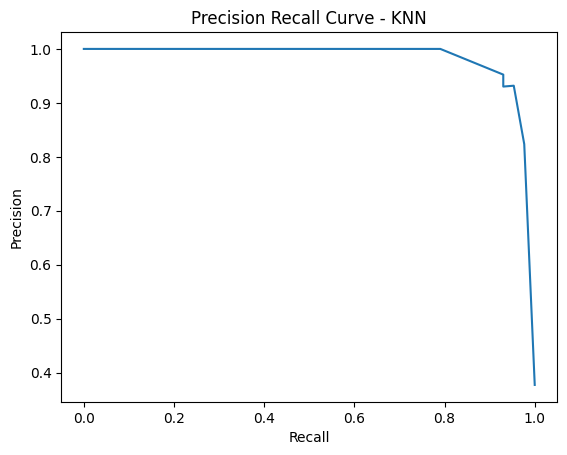

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
!pip install ucimlrepo
from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import precision_recall_curve
import numpy as np

# Fetch dataset
breast_cancer_wisconsin_diagnostic = fetch_ucirepo(id=17)

X = breast_cancer_wisconsin_diagnostic.data.features
y = breast_cancer_wisconsin_diagnostic.data.targets
y = y.values.ravel()

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train KNN Model
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# Prediction
y_pred_knn = knn.predict(X_test)

# Evaluation
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))
print("Classification Report:\n", classification_report(y_test, y_pred_knn))

# Convert y_test labels to numerical (0 and 1) for precision_recall_curve
y_test_numeric = np.where(y_test == 'M', 1, 0)

# Precision Recall Curve
y_prob_knn = knn.predict_proba(X_test)[:,1]
precision, recall, _ = precision_recall_curve(y_test_numeric, y_prob_knn)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision Recall Curve - KNN")
plt.show()

SVM Accuracy: 0.956140350877193
Confusion Matrix:
 [[68  3]
 [ 2 41]]
Classification Report:
               precision    recall  f1-score   support

           B       0.97      0.96      0.96        71
           M       0.93      0.95      0.94        43

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



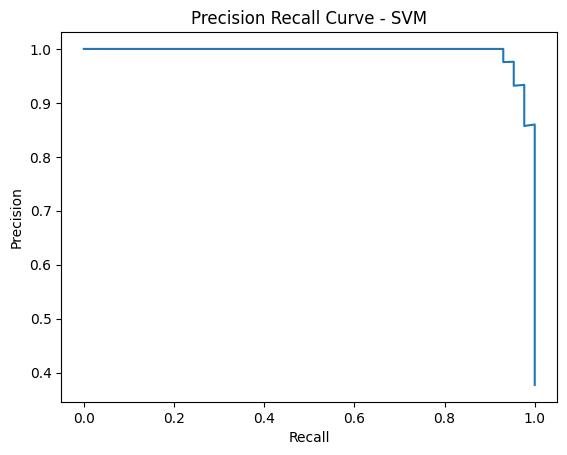

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import precision_recall_curve
import numpy as np

# Fetch dataset
breast_cancer_wisconsin_diagnostic = fetch_ucirepo(id=17)

X = breast_cancer_wisconsin_diagnostic.data.features
y = breast_cancer_wisconsin_diagnostic.data.targets
y = y.values.ravel()

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train SVM Model
svm = SVC(kernel='linear', probability=True)
svm.fit(X_train, y_train)

# Prediction
y_pred_svm = svm.predict(X_test)

# Evaluation
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))
print("Classification Report:\n", classification_report(y_test, y_pred_svm))

# Convert y_test labels to numerical (0 and 1) for precision_recall_curve
y_test_numeric = np.where(y_test == 'M', 1, 0)

# Precision Recall Curve
y_prob_svm = svm.predict_proba(X_test)[:,1]
precision, recall, _ = precision_recall_curve(y_test_numeric, y_prob_svm)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision Recall Curve - SVM")
plt.show()

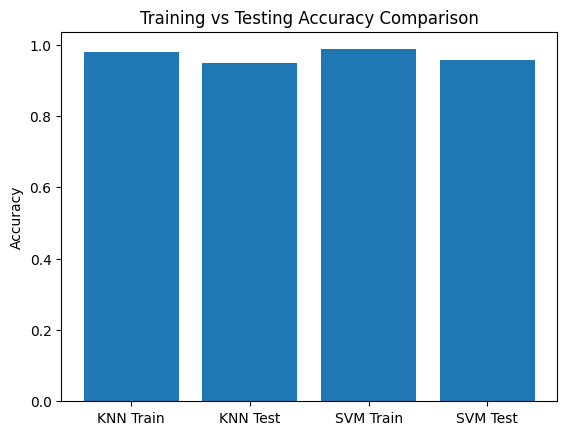

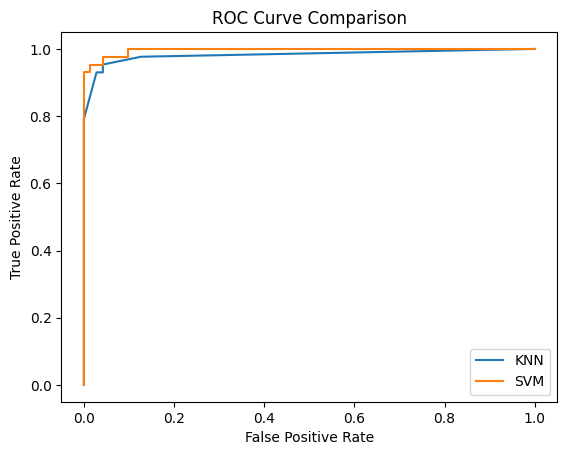

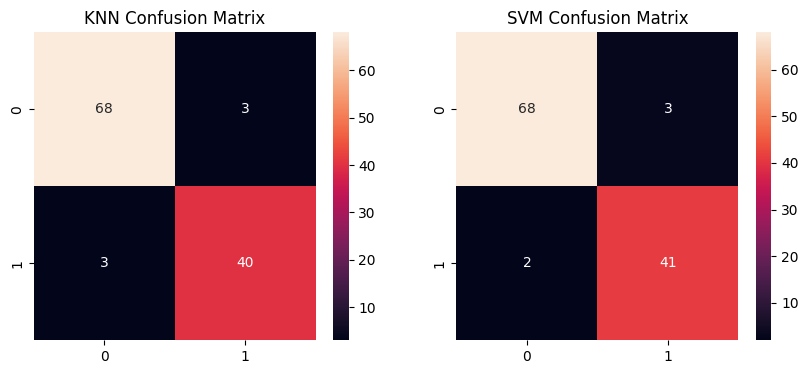

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, confusion_matrix

# Training and Testing Accuracy
train_acc_knn = knn.score(X_train, y_train)
test_acc_knn = knn.score(X_test, y_test)

train_acc_svm = svm.score(X_train, y_train)
test_acc_svm = svm.score(X_test, y_test)

labels = ['KNN Train','KNN Test','SVM Train','SVM Test']
values = [train_acc_knn, test_acc_knn, train_acc_svm, test_acc_svm]

plt.bar(labels, values)
plt.ylabel("Accuracy")
plt.title("Training vs Testing Accuracy Comparison")
plt.show()

# ROC Curve
from sklearn.metrics import roc_curve

fpr_knn, tpr_knn, _ = roc_curve(y_test_numeric, y_prob_knn)
fpr_svm, tpr_svm, _ = roc_curve(y_test_numeric, y_prob_svm)

plt.plot(fpr_knn, tpr_knn, label="KNN")
plt.plot(fpr_svm, tpr_svm, label="SVM")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

# Confusion Matrix Heatmap

cm_knn = confusion_matrix(y_test, y_pred_knn)
cm_svm = confusion_matrix(y_test, y_pred_svm)

fig, ax = plt.subplots(1,2, figsize=(10,4))

sns.heatmap(cm_knn, annot=True, fmt='d', ax=ax[0])
ax[0].set_title("KNN Confusion Matrix")

sns.heatmap(cm_svm, annot=True, fmt='d', ax=ax[1])
ax[1].set_title("SVM Confusion Matrix")

plt.show()